# Modell zur Ausnutzung revolvierender Kreditlinien für Kleinunternehmen

## Zusammenfassung für die Geschäftsleitung

Revolvierende Kreditlinien sind zugesagt, aber nicht vollständig in Anspruch genommen, sodass der **finanzierte Saldo** eines Kreditgebers — und das dafür vorzuhaltende ökonomische Kapital — davon abhängt, wie viel von jeder Linie der Kreditnehmer tatsächlich nutzt. Diese Analyse modelliert die **Ausnutzungsrate** (in Anspruch genommener Saldo / zugesagtes Limit) für eine Arbeitsstichprobe von **100 revolvierenden Kreditlinien von Kleinunternehmen**, um die finanzierte Risikoposition zu prognostizieren und die Kapitalplanung zu unterstützen.

Wir kombinieren vier SAS-Prozeduren, die jeweils eine eigene Planungsfrage beantworten:

- **PROC MEANS** profiliert den in Anspruch genommenen Saldo und die Ausnutzung nach interner **Risikoklasse**. Die durchschnittliche Ausnutzung steigt monoton über die Klassen hinweg — 0.307 (A), 0.359 (B), 0.416 (C), 0.488 (D), 0.518 (E) — und stellt so die empirische Beziehung zwischen Kreditqualität und Nutzung her, die in die Annahmen zur Risikoposition bei Ausfall einfließt.
- **PROC REG** modelliert die Ausnutzung anhand der Fundamentaldaten des Kreditnehmers (Schuldendienstdeckung, Umsatzvolatilität, Alter der Linie, frühere Ausnutzung) und des makroökonomischen Umfelds (Arbeitslosigkeit, kurzfristiger Zins). Das Modell erklärt 45 % der Varianz (R-Square 0.448, F p < .0001), und die standardisierten Schätzer weisen der **Schuldendienstdeckung** (-0.45) und der **früheren Ausnutzung** (0.41) den Rang der dominierenden Einflussgrößen zu. Alle Varianzinflationsfaktoren bleiben unter 1.17, sodass Multikollinearität kein Problem darstellt.
- **PROC GLM** prüft, ob sich die Ausnutzung nach **Branchensegment** unterscheidet, nachdem diese Einflussgrößen kontrolliert wurden, unter Verwendung Tukey-adjustierter Kleinste-Quadrate-Mittelwerte. Der Brancheneffekt ist insgesamt grenzwertig (F p = 0.060), aber **Bau** nimmt bei konstant gehaltener Kreditnehmerqualität signifikant mehr in Anspruch als **Einzelhandel** (p = 0.007) und **Gesundheitswesen** (p = 0.024).
- **PROC UNIVARIATE** extrahiert das 2.5.- und das 97.5.-Perzentil der Ausnutzung — ein Band von **0.121 bis 0.744** um einen Mittelwert von 0.404 — und definiert damit das plausible Niedrig-/Hoch-Inanspruchnahme-Szenario für Stress- und ökonomische Kapitaltests.

Zusammen ermöglichen diese Ergebnisse der Bank, ein statisches Buch mit zugesagten Limits in eine **zukunftsgerichtete Prognose des finanzierten Saldos** mit belastbaren, prüfbaren Annahmen zu übersetzen. Die Stichprobe von 100 Linien ist der Ausschnitt, den diese Umgebung ausführt; dasselbe Programm skaliert unverändert auf ein vollständiges Produktionsbuch.

## Datenquellen

Der Datensatz wird synthetisch innerhalb des Notebooks erzeugt (keine externen Dateien, kein Netzwerk). Jede Zeile ist eine revolvierende Kreditlinie eines Kleinunternehmens, beobachtet zu einem bestimmten Zeitpunkt.

| Variable | Typ | Beschreibung |
|----------|------|-------------|
| `line_id` | Num | Eindeutige Kennung der Kreditlinie |
| `risk_grade` | Char | Interne Risikoklasse (A beste … E schwächste) |
| `industry` | Char | Branchensegment des Kreditnehmers (Retail, Services, Construction, Manufacturing, Healthcare) |
| `committed_limit` | Num | Zugesagter Kreditlinienbetrag ($000er) |
| `months_on_book` | Num | Alter der Linie (Monate seit Vergabe) |
| `dscr` | Num | Schuldendienstdeckungsgrad |
| `rev_volatility` | Num | Nachlaufende Umsatzvolatilität (Variationskoeffizient) |
| `prior_util` | Num | Ausnutzungsrate in der Vorperiode (0–1) |
| `unemp_rate` | Num | Lokale Arbeitslosenquote (%) zum Beobachtungszeitpunkt |
| `short_rate` | Num | Vorherrschender kurzfristiger Referenzzins (%) |
| `utilization_rate` | Num | In Anspruch genommener Saldo / zugesagtes Limit (0–1), die modellierte Zielgröße |
| `drawn_balance` | Num | Finanzierter Saldo = utilization_rate × committed_limit ($000er) |

**Umfang:** Der DATA step ist so geschrieben, dass er ein vollständiges Buch erzeugt, aber diese Umgebung läuft unlizenziert und begrenzt die Ausgabe auf die ersten **100 Linien** — die durchgängig analysierte Arbeitsstichprobe. Diese 100 Linien umfassen alle 5 Risikoklassen (A–E) und alle 5 Branchensegmente. Die Ausnutzung wird aus einer logit-verknüpften latenten Größe simuliert, die von den obigen Kovariaten plus Rauschen bestimmt wird, sodass die Regression und das GLM ein echtes, interpretierbares Signal zurückgewinnen. Die Laufzeit liegt deutlich unter 60 Sekunden.

## 1. Erzeugung des synthetischen Kreditlinien-Portfolios

Die erste Zelle baut ein realistisches Buch revolvierender Kreditlinien von Kleinunternehmen auf (diese Umgebung begrenzt den Lauf auf die ersten **100 Linien**). Wir ziehen für jede Linie eine Risikoklasse und ein Branchensegment und simulieren dann die Fundamentaldaten des Kreditnehmers und das makroökonomische Umfeld. Die Ausnutzung wird aus einem **logit-verknüpften latenten Score** erzeugt, sodass schwächere Klassen, eine geringere Schuldendienstdeckung, eine höhere Umsatzvolatilität, eine hartnäckigere frühere Ausnutzung und ein angespanntes makroökonomisches Umfeld allesamt den in Anspruch genommenen Anteil nach oben treiben — genau die Struktur, die die Regression und das GLM weiter unten zurückgewinnen sollen. Der finanzierte `drawn_balance` ist dann die Ausnutzung multipliziert mit dem zugesagten Limit.

In [1]:
/* --------------------------------------------------------
   Generate a synthetic portfolio of small-business
   revolving credit lines. Utilization is simulated from a
   logit-linked latent driven by credit, borrower, and
   macro covariates so the models below recover real signal.
   -------------------------------------------------------- */
DATEN credit_lines;
    AUFRUFEN streaminit(20260605);

    BEZEICHNUNG line_id          = "Credit-line identifier"
          risk_grade       = "Internal risk grade (A-E)"
          industry         = "Borrower industry segment"
          committed_limit  = "Committed limit ($000s)"
          months_on_book   = "Line seasoning (months)"
          dscr             = "Debt-service coverage ratio"
          rev_volatility   = "Revenue volatility (CV)"
          prior_util       = "Prior-period utilization rate"
          unemp_rate       = "Local unemployment rate (%)"
          short_rate       = "Short-term reference rate (%)"
          utilization_rate = "Utilization rate (drawn/limit)"
          drawn_balance    = "Funded balance ($000s)";

    /* Lookup arrays for categorical attributes */
    FELD grades[5] $1 _temporary_ ('A' 'B' 'C' 'D' 'E');
    FELD segs[5] $13 _temporary_
        ('Retail' 'Services' 'Construction'
         'Manufacturing' 'Healthcare');

    AUSFÜHRUNG line_id = 1 BIS 4000;

        /* Risk grade: more mass in the middle grades */
        g = rand('TABLE', 0.15, 0.28, 0.30, 0.18, 0.09);
        risk_grade = grades[g];

        /* Industry segment: roughly even with a retail tilt */
        s = rand('TABLE', 0.28, 0.24, 0.18, 0.16, 0.14);
        industry = segs[s];

        /* Committed limit: log-normal, $25k to ~$1.5M */
        committed_limit = round(25 + EXP(rand('NORMAL', 4.6, 0.55)), 1);

        /* Borrower fundamentals */
        months_on_book = round(rand('UNIFORM') * 84 + 3, 1);
        dscr           = round(0.8 + rand('GAMMA', 4) * 0.30, 0.01);
        rev_volatility = round(0.10 + rand('GAMMA', 2) * 0.07, 0.001);
        prior_util     = MIN(0.98, MAX(0.02,
                             rand('BETA', 2, 3)));

        /* Macro environment at the observation date */
        unemp_rate = round(rand('NORMAL', 5.2, 1.1), 0.1);
        WENN unemp_rate < 2.5 DANN unemp_rate = 2.5;
        short_rate = round(rand('NORMAL', 4.0, 0.8), 0.01);
        WENN short_rate < 0 DANN short_rate = 0;

        /* Grade severity index: A=0 ... E=4 */
        grade_sev = g - 1;

        /* Logit-linked latent utilization score.
           Weaker grades, lower DSCR, higher volatility,
           sticky prior use, and macro stress raise usage. */
        eta = -0.60
              + 0.34 * grade_sev
              - 0.55 * (dscr - 1.4)
              + 1.10 * (rev_volatility - 0.24)
              + 1.80 * (prior_util - 0.45)
              + 0.16 * (unemp_rate - 5.2)
              + 0.07 * (short_rate - 4.0)
              - 0.004 * (months_on_book - 40);

        /* Industry-segment shifts on the latent scale */
        AUSWÄHLEN (industry);
            FALLS ('Construction')  eta = eta + 0.30;
            FALLS ('Retail')        eta = eta + 0.12;
            FALLS ('Manufacturing') eta = eta - 0.08;
            FALLS ('Healthcare')    eta = eta - 0.22;
            ANDERNFALLS; /* Services = reference */
        ENDE;

        /* Add noise, map to (0,1) via logistic link */
        eta = eta + rand('NORMAL', 0, 0.45);
        utilization_rate = round(1 / (1 + EXP(-eta)), 0.0001);

        /* Funded balance follows from utilization */
        drawn_balance = round(utilization_rate * committed_limit,
                              0.1);

        AUSGABE;
    ENDE;

    BEHALTEN line_id risk_grade industry committed_limit
         months_on_book dscr rev_volatility prior_util
         unemp_rate short_rate utilization_rate drawn_balance;
AUSFÜHREN;

NOTE: DATA credit_lines

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote credit_lines (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.08 seconds
  cpu   0.08 seconds


## 2. Finanzierte Risikoposition nach Risikoklasse

Modelle für ökonomisches Kapital müssen wissen, wie der finanzierte Saldo und die Ausnutzung über die Kreditqualität hinweg variieren. **PROC MEANS** fasst den in Anspruch genommenen Saldo und die Ausnutzung für jede interne Risikoklasse mit dem vollständigen Verteilungsbild zusammen — Mittelwert, Standardabweichung, Quartile und Spannweite. Wir erwarten, dass die Ausnutzung monoton von Klasse A zu Klasse E ansteigt, was direkt in die Annahmen zur Risikoposition bei Ausfall für das revolvierende Buch einfließt.

In [2]:
/* Drawn balance and utilization by internal risk grade */
PROZEDUR MITTELWERTE DATEN=credit_lines NWAY maxdec=3
          n mean std MIN q1 MEDIAN q3 MAX;
    KLASSE risk_grade;
    VAR drawn_balance utilization_rate committed_limit;
AUSFÜHREN;

                                                  The MEANS Procedure

                                       Analysis Variable : Funded balance ($000s)

        Internal risk grade (A-E)          N Obs           Mean        Std Dev        Minimum  Lower Quartile         Median  Upper Quartile        Maximum
        ---------------------------------------------------------------------------------------------------------------------------------------------------
        A                                     18         41.428         24.051          7.700          27.650         37.200          55.150        103.300
        B                                     26         42.412         23.153          7.800          25.175         34.550          61.925         84.700
        C                                     29         55.997         50.693         13.300          33.300         45.000          58.950        287.400
        D                                     18         75.917   

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Einflussgrößen der Ausnutzung — multiple Regression

**PROC REG** modelliert die Ausnutzungsrate anhand der Fundamentaldaten des Kreditnehmers und des makroökonomischen Umfelds. Wir fordern an:

- **CLB** — 95-%-Konfidenzgrenzen für jeden Koeffizienten, damit das Kreditteam Effektspannen statt Punktschätzungen berichten kann.
- **VIF** und **TOL** — Varianzinflationsfaktoren und Toleranz, um zu bestätigen, dass die Kovariaten nicht kollinear sind.
- **STB** — standardisierte Schätzer, um die Einflussgrößen auf einer vergleichbaren Skala zu ordnen.

Die Koeffizienten beantworten die Planungsfrage direkt: Wie stark verändert eine Bewegung um eine Einheit in jeder Einflussgröße den erwarteten in Anspruch genommenen Anteil einer Linie? Das angepasste Modell erklärt 45 % der Ausnutzungsvarianz (R-Square 0.448, Gesamt-F p < .0001). PROC REG gibt außerdem sein standardmäßiges ODS-Diagnosepanel aus — Residuen gegen Vorhersage, ein Residuenhistogramm, Residuen gegen Beobachtungsreihenfolge, ein Normal-Q-Q-Diagramm und ein Cook's-D-Einflussdiagramm — unterhalb der Tabelle dargestellt. Die Prozedur ist eine interaktive RUN-Gruppen-Prozedur, daher schließen wir sie mit `quit;`, um die Ausgabe zu leeren.

                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
                          Dependent Variable: utilization_rate Utilization rate (drawn/limit)                           

Source                 DF  Sum of Squares  Mean Square   F Value    Pr > F
---------------  --------  --------------  -----------  --------  --------
Model                   6         1.33856      0.22309     12.56    <.0001
Error                  93         1.65226      0.01777                    
Corrected Total        99         2.99082                                 

Root MSE           0.13329    R-Square            0.4476
Dependent Mean       0.40374    Adj R-Sq            0.4119
Coeff Var         33.01401

                                                                           Parameter Estimates                      

NOTE: PROC REG data=credit_lines

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.


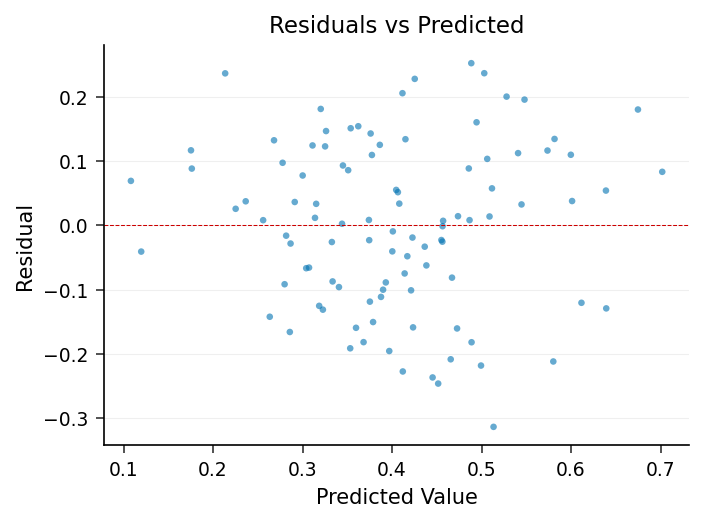

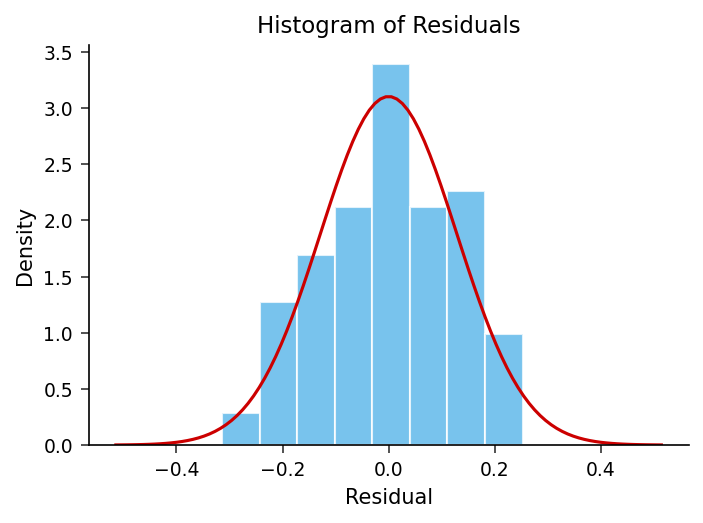

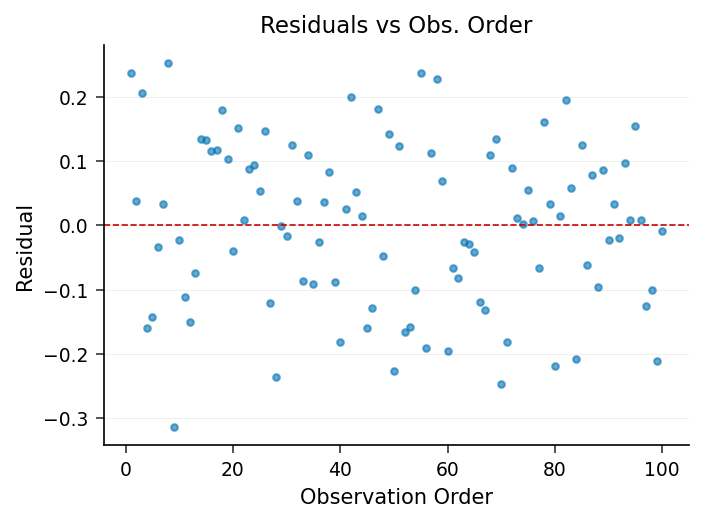

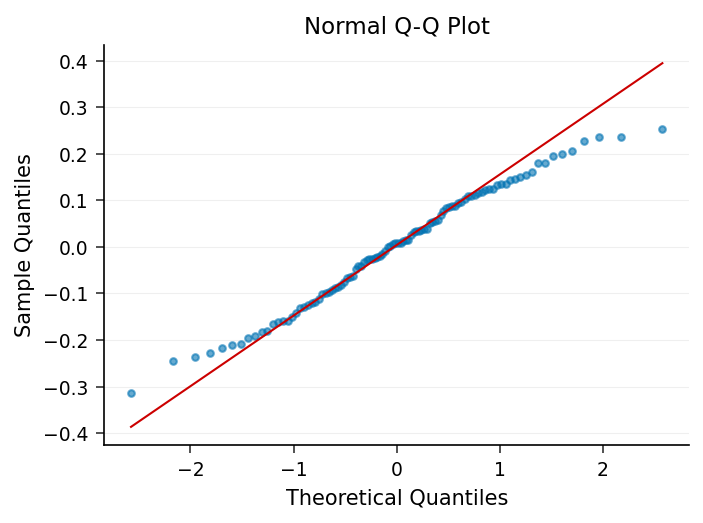

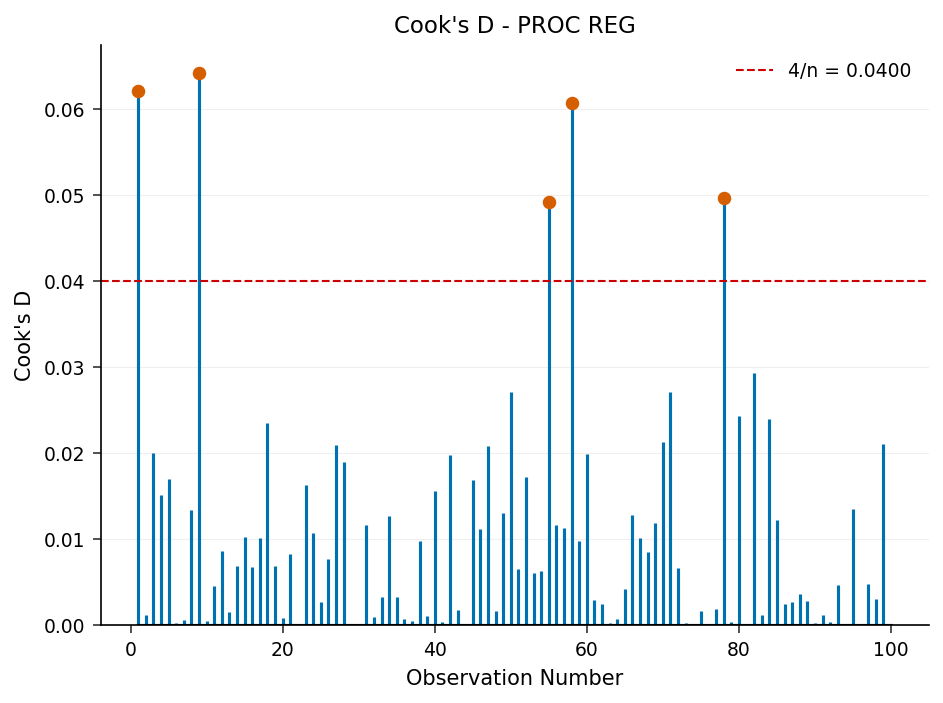

In [3]:
/* Utilization rate vs borrower and macro covariates */
PROZEDUR REG DATEN=credit_lines;
    MODELL utilization_rate =
          dscr rev_volatility prior_util
          months_on_book unemp_rate short_rate
          / clb stb vif tol;
AUSFÜHREN;
QUIT;

## 4. Ausnutzung nach Branchensegment — allgemeines lineares Modell

Nehmen manche Branchen ihre Linien aggressiver in Anspruch, sobald wir die Kreditnehmerqualität und das makroökonomische Umfeld berücksichtigen? **PROC GLM** behandelt `industry` als Klassifikationseffekt und fügt dieselben stetigen Kovariaten als Kovarianzanalyse-Kontrollen hinzu. Wir fordern an:

- **SOLUTION** — die Parameterschätzer für jede Branchenstufe relativ zur Referenz.
- **LSMEANS / PDIFF / ADJUST=TUKEY / CL** — Tukey-adjustierte Kleinste-Quadrate-Mittelwerte und paarweise Differenzen, die kovariaten-adjustierte Ausnutzung für jedes Segment.

GLM gibt dasselbe ODS-Diagnosepanel wie REG aus, zuzüglich eines Balkendiagramms der Kleinste-Quadrate-Mittelwerte nach Branche (mit Konfidenzintervallen), unterhalb der Tabellen dargestellt. Es ist ebenfalls eine RUN-Gruppen-Prozedur, daher endet es mit `quit;`.

                            The GLM Procedure                            
   Dependent Variable: utilization_rate Utilization rate (drawn/limit)   

Source                DF  Sum of Squares  Mean Square   F Value    Pr > F
--------------  --------  --------------  -----------  --------  --------
industry               4         0.15847      0.03962      2.35    0.0604
dscr                   1         0.68916      0.68916     40.83    <.0001
rev_volatility         1         0.13434      0.13434      7.96    0.0059
prior_util             1         0.43034      0.43034     25.49    <.0001
unemp_rate             1         0.14344      0.14344      8.50    0.0045
short_rate             1         0.08861      0.08861      5.25    0.0243
Error                 90         1.51926      0.01688                    

Root MSE           0.12993    R-Square            0.4920
Adj R-Sq            0.4412

                        Parameter Estimates                        

Parameter              Estimat

NOTE: PROC GLM data=credit_lines

NOTE: Warning message:
NOTE: In readLines(file("stdin")) : incomplete final line found on 'stdin'
NOTE: ODS plot written: glm_residuals_vs_predicted.spec.json
NOTE: ODS plot written: glm_residual_histogram_panel.spec.json
NOTE: ODS plot written: glm_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: glm_qq_plot.spec.json
NOTE: ODS plot written: glm_lsmeans_industry.spec.json
NOTE: PROC GLM ODS Graphics generated.
NOTE: PROC GLM statement used.


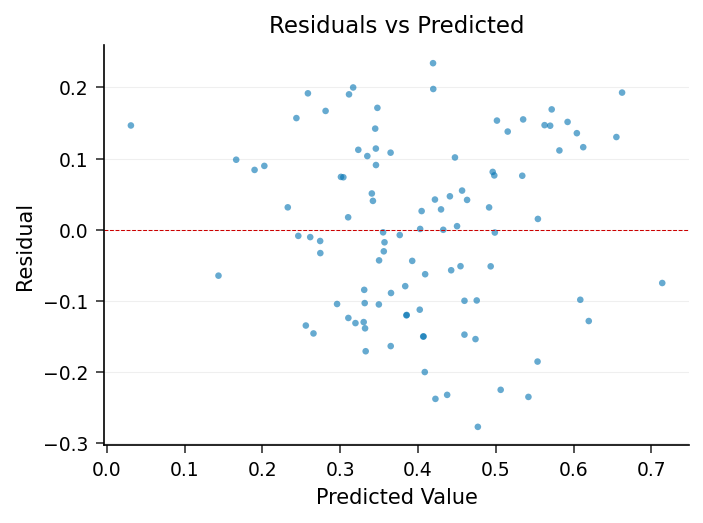

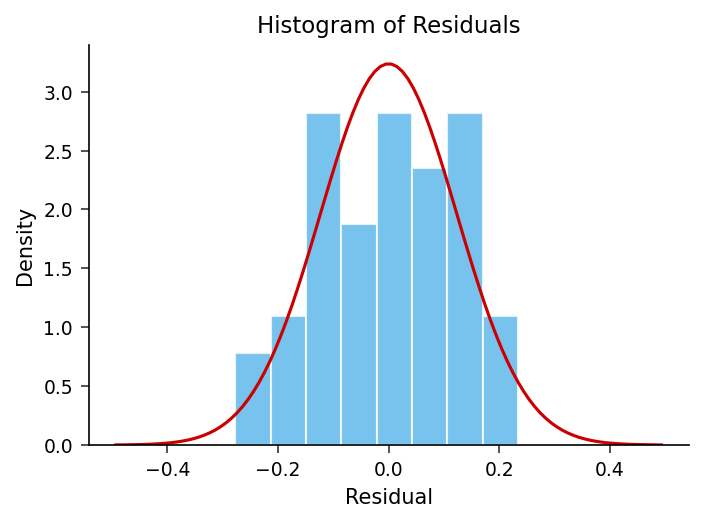

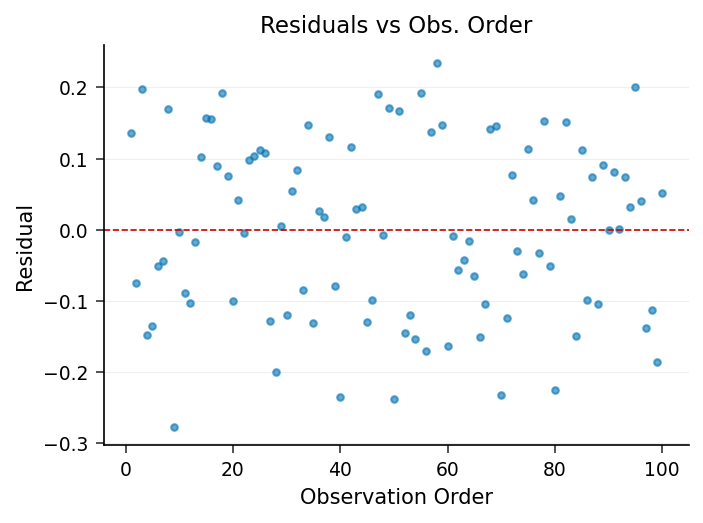

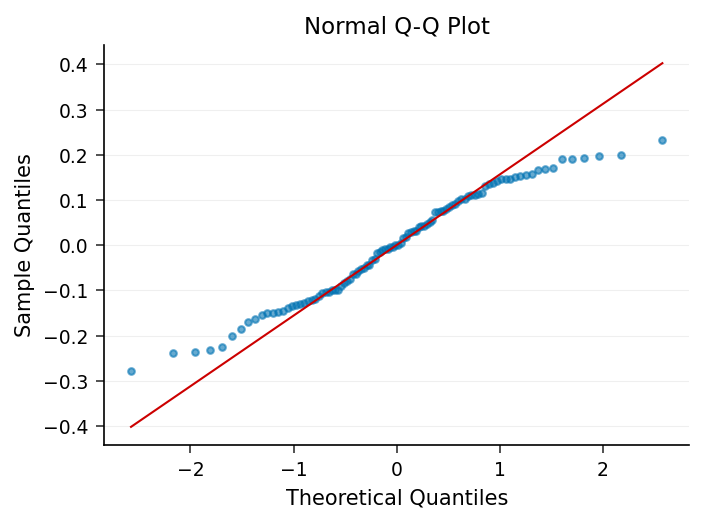

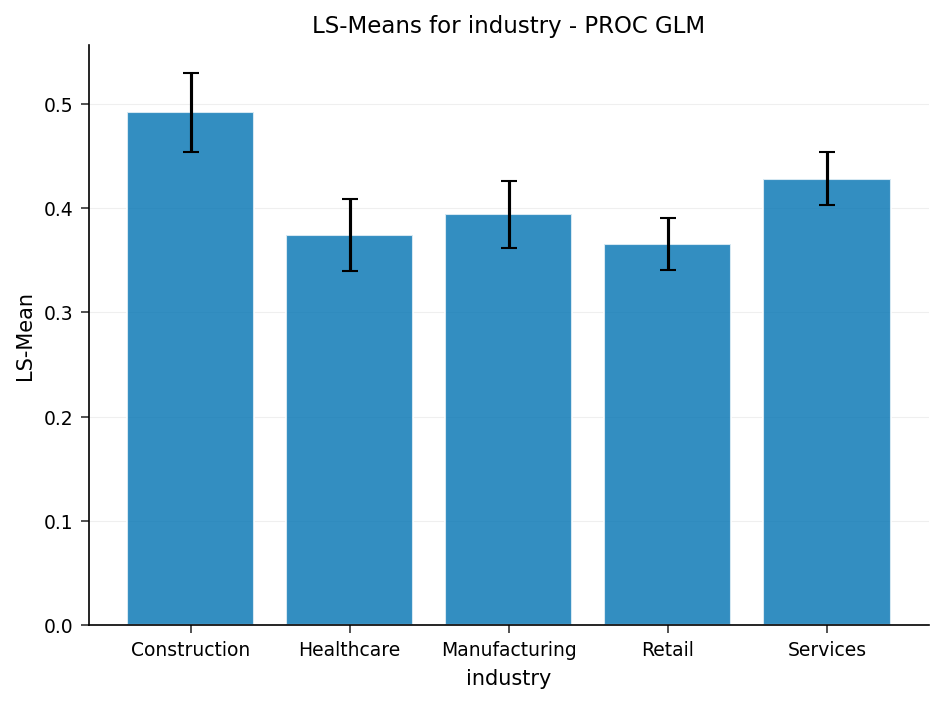

In [4]:
/* Utilization by industry segment, adjusting for drivers */
PROZEDUR GLM DATEN=credit_lines;
    KLASSE industry;
    MODELL utilization_rate =
          industry dscr rev_volatility prior_util
          unemp_rate short_rate
          / SOLUTION ss3;
    LSMEANS industry / PDIFF ADJUST=TUKEY cl;
AUSFÜHREN;
QUIT;

## 5. Ausnutzungsband für Stress und ökonomisches Kapital

Die Kapitalplanung benötigt die **Ränder** der Ausnutzungsverteilung, nicht nur den Mittelwert. Da fraktionale Perzentile am besten mit **PROC UNIVARIATE** statt mit PROC MEANS ermittelt werden, verwenden wir `PCTLPTS=`, um das **2.5.- und das 97.5.-Perzentil** der Ausnutzung zu extrahieren. Das resultierende Band definiert ein plausibles Niedrig-/Hoch-Inanspruchnahme-Szenario für den Stresstest des finanzierten Saldos.

In [5]:
/* 2.5th / 97.5th utilization percentiles for stress band */
PROZEDUR UNIVARIATE DATEN=credit_lines NOPRINT;
    VAR utilization_rate;
    AUSGABE out=util_band
           mean=util_mean
           pctlpts=2.5 97.5
           pctlpre=util_p
           pctlname=lo hi;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=util_band noobs BEZEICHNUNG;
    BEZEICHNUNG util_mean = "Mean utilization"
          util_plo  = "2.5th pctl (stress low)"
          util_phi  = "97.5th pctl (stress high)";
AUSFÜHREN;


Mean utilization  2.5th pctl (stress low)  97.5th pctl (stress high)
----------------  -----------------------  -------------------------
        0.403738                   0.1212                     0.7438



NOTE: PROC UNIVARIATE
NOTE: Output dataset util_band has 1 observations and 3 variables.
NOTE: PROC PRINT data=util_band

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


## 6. Interpretation und nächste Schritte

**Was das Modell zeigt**

- **Die Risikoklasse bestimmt die finanzierte Risikoposition.** Das PROC-MEANS-Profil zeigt, dass die durchschnittliche Ausnutzung monoton von der stärksten zur schwächsten Klasse ansteigt — 0.307 (A), 0.359 (B), 0.416 (C), 0.488 (D), 0.518 (E). Da der in Anspruch genommene Saldo die Ausnutzung mal dem zugesagten Limit ist, wandeln schwächere Klassen einen größeren Anteil ihrer Zusagen in finanzierte Salden um — die zentrale Eingabe für die Risikoposition bei Ausfall und das ökonomische Kapital revolvierender Linien. (Der durchschnittliche in Anspruch genommene Saldo steigt ebenfalls mit der Klasse und erreicht in dieser Stichprobe von 100 Linien seinen Höchstwert bei Klasse D; die kleine Klasse-E-Zelle mit 9 Linien enthält ein sehr großes Limit, das ihren Mittelwert des zugesagten Limits verzerrt — genau die Art von Kleinzellenverhalten, das das vollständige Buch glätten würde.)
- **Die Fundamentaldaten des Kreditnehmers dominieren die Regression.** In PROC REG trägt die **Schuldendienstdeckung** den größten standardisierten Koeffizienten (-0.45) und wirkt schützend — jede zusätzliche Einheit Deckung senkt die Ausnutzung um etwa 0.11 (95-%-KG -0.152 bis -0.075). Die **frühere Ausnutzung** ist die nächststärkste Einflussgröße (standardisiert 0.41, Schätzer +0.38): Linien, die zuvor stark in Anspruch genommen wurden, bleiben hoch ausgenutzt. Die **Umsatzvolatilität** (+0.37, p = 0.021) und die makroökonomischen Terme — **Arbeitslosigkeit** (+0.036, p = 0.009) und der **kurzfristige Zins** (+0.036, p = 0.036) — sind allesamt positiv und signifikant, sodass ein Abschwung die portfolioweit finanzierten Salden mechanisch anhebt. Alle VIFs liegen unter 1.17, weit unter dem üblichen Schwellenwert von 10, was bestätigt, dass die Einflussgrößen nicht kollinear sind, und die CLB-Intervalle schließen die Null für jeden Effekt außer dem Alter der Linie aus. Die Residuendiagnostik verhält sich gutartig: Die Residuen streuen zufällig um die Null, das Histogramm ist annähernd normalverteilt, und das Q-Q-Diagramm ist nahezu linear mit nur milder Randabweichung; Cook's D markiert vier mäßig einflussreiche Linien (über 4/n = 0.04), die einen Blick auf die Datenqualität wert sind.
- **Die Branche fügt ein grenzwertiges Restsignal hinzu.** Nach Kontrolle der Kreditnehmer- und Makrokovariaten ist der Gesamt-Brancheneffekt in PROC GLM nur grenzwertig (Typ-III-F p = 0.060). Doch die Tukey-adjustierten Kleinste-Quadrate-Mittelwerte trennen die Segmente weiterhin: **Bau** hat die höchste adjustierte Ausnutzung (0.492), gefolgt von **Dienstleistungen** (0.428), wobei **Fertigung** (0.394), **Gesundheitswesen** (0.374) und **Einzelhandel** (0.366) darunter geclustert sind. Die paarweisen Tests bestätigen, dass Bau signifikant mehr in Anspruch nimmt als **Einzelhandel** (Differenz 0.126, p = 0.007) und **Gesundheitswesen** (0.118, p = 0.024); die übrigen paarweisen Abstände sind nicht signifikant. Dies steht im Einklang damit, wie die Intensität des Betriebskapitals nach Sektor variiert, und markiert Bau als das zu beobachtende Segment.

**Wie man es nutzt**

- **Prognostizieren Sie finanzierte Salden**, indem Sie die Regression auf zukünftige Makropfade anwenden (steigende Arbeitslosigkeit, höhere kurzfristige Zinsen), um den in Anspruch genommenen Saldo des Portfolios unter jedem Szenario zu projizieren.
- **Legen Sie das Stressband für das ökonomische Kapital** anhand der PROC-UNIVARIATE-Perzentile fest: Die Ausnutzung reicht plausibel von **0.121** (2.5.) bis **0.744** (97.5.) um einen Mittelwert von 0.404 und bemisst so das Niedrig-/Hoch-Inanspruchnahme-Szenario für einen Abschwung.
- **Differenzieren Sie Limits und Bepreisung** nach Risikoklasse und nach der erhöhten adjustierten Inanspruchnahme im Bau, indem Sie die höhere erwartete Ausnutzung — und die höhere finanzierte Risikoposition — bepreisen, die die MEANS- und GLM-Ergebnisse quantifizieren.

**Erweiterungen**

Ersetzen Sie den OLS-Link durch eine fraktionale Response- oder Beta-Regression (PROC GLIMMIX / PROC NLMIXED), um die 0–1-Schranke zu respektieren, fügen Sie einen Kreditnehmer-Zufallseffekt für Mehrperioden-Panels hinzu und speisen Sie die angepasste Ausnutzung direkt in eine Engine für Verlustquote bei Ausfall und ökonomisches Kapital ein. Ein erneuter Lauf auf dem vollständigen (unbegrenzten) Buch würde die kleinen Risikoklassen- und Branchenzellen straffen und den grenzwertigen Branchen-F-Test wahrscheinlich schärfen.